In [1]:
!git clone https://github.com/AGupta-23/RetinaScan

Cloning into 'RetinaScan'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 30 (delta 6), reused 28 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 70.12 KiB | 3.51 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
import cv2
import numpy as np
import torch
from torchvision import transforms

# ImageNet stats — required because we're using ImageNet-pretrained ResNet50
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Define the transform pipeline
preprocess_transform = transforms.Compose([
    transforms.ToPILImage(),          # cv2/numpy -> PIL (torchvision transforms expect PIL or Tensor)
    transforms.Resize((224, 224)),    # resize to ResNet50 input size
    transforms.ToTensor(),            # converts to tensor AND scales pixels to [0,1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # standardize using ImageNet stats
])

def load_and_preprocess_image(image_path):
    """
    Loads an image from disk and applies resize + normalize.
    Returns a normalized tensor ready for the model.
    """
    img = cv2.imread(image_path)              # BGR by default
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB (torchvision expects RGB)
    tensor = preprocess_transform(img)
    return tensor

In [3]:
# Replace with an actual filename from your clean_labels.csv
test_image_path = "/kaggle/input/competitions/aptos2019-blindness-detection/train_images/001639a390f0.png"

tensor = load_and_preprocess_image(test_image_path)

print("Tensor shape:", tensor.shape)   # should be torch.Size([3, 224, 224])
print("Tensor dtype:", tensor.dtype)   # should be torch.float32
print("Min value:", tensor.min().item())
print("Max value:", tensor.max().item())

Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Min value: -2.1007792949676514
Max value: 2.248908281326294


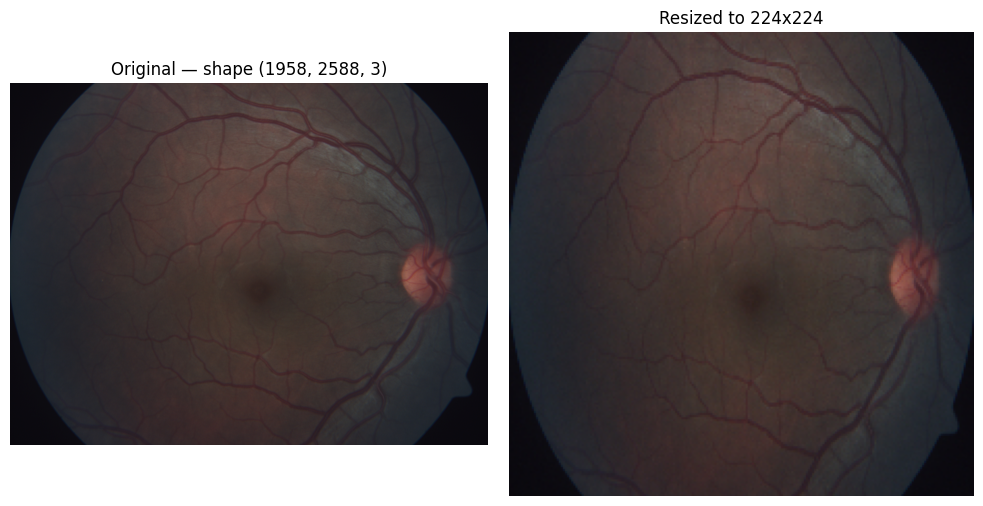

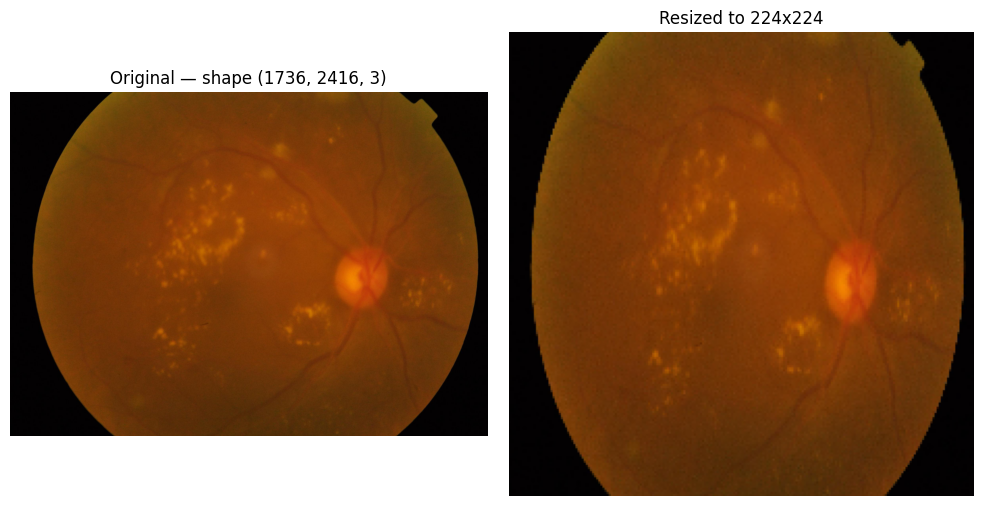

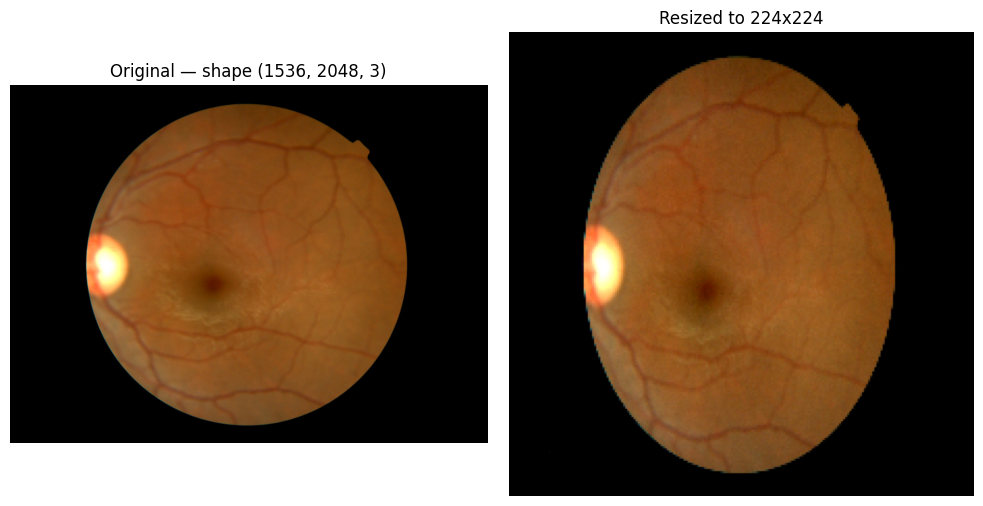

In [4]:
import matplotlib.pyplot as plt
import cv2

def show_preprocessing_comparison(image_path):
    # Load original
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Resized only (no normalization, so it's still viewable as an image)
    resized = cv2.resize(original, (224, 224))

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original)
    axes[0].set_title(f"Original — shape {original.shape}")
    axes[0].axis('off')

    axes[1].imshow(resized)
    axes[1].set_title("Resized to 224x224")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Test on 3-4 different images (pick varied ones — different aspect ratios if possible)
sample_paths = [
    "/kaggle/input/competitions/aptos2019-blindness-detection/train_images/0097f532ac9f.png",
    "/kaggle/input/competitions/aptos2019-blindness-detection/train_images/042470a92154.png",
    "/kaggle/input/competitions/aptos2019-blindness-detection/train_images/0924cec998fa.png",
]

for path in sample_paths:
    show_preprocessing_comparison(path)

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your Phase 3 output
df = pd.read_csv("/kaggle/working/RetinaScan/data/clean_labels.csv")  # adjust path to wherever you saved it

# First split: 70% train, 30% temp (which becomes val+test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],     # preserves class ratio
    random_state=42            # reproducibility — same split every run
)

# Second split: split the 30% temp into val (15%) and test (15%) — i.e., 50/50 of temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

# Sanity checks
print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("\nClass balance check:")
print("Train:", train_df['label'].value_counts(normalize=True).to_dict())
print("Val:  ", val_df['label'].value_counts(normalize=True).to_dict())
print("Test: ", test_df['label'].value_counts(normalize=True).to_dict())

# Save splits
train_df.to_csv("/kaggle/working/train_split.csv", index=False)
val_df.to_csv("/kaggle/working/val_split.csv", index=False)
test_df.to_csv("/kaggle/working/test_split.csv", index=False)

Train: 2563 | Val: 549 | Test: 550

Class balance check:
Train: {1: 0.5072181037846274, 0: 0.4927818962153726}
Val:   {1: 0.5063752276867031, 0: 0.4936247723132969}
Test:  {1: 0.5072727272727273, 0: 0.49272727272727274}


In [6]:
train_df['filename'].head()

3429    ee3fe7809e6a
1208    53704c80f0d8
3317    e6552b7432b3
2987    cfd1bd0fcbb4
2715    bb9a3d835a94
Name: filename, dtype: object

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import os
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class RetinaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        """
        df: DataFrame with 'filename' and 'label' columns
        image_dir: folder containing the actual .png images
        transform: preprocessing pipeline (resize/normalize)
        """
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        # Total number of samples — DataLoader uses this to know when an epoch ends
        return len(self.df)

    def __getitem__(self, idx):
        # Called by DataLoader for every single sample it needs
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['filename'] + ".png")

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row['label'], dtype=torch.float32)  # float for BCE loss later
        return img, label


# Reuse the same transform pipeline from Task 4.1
preprocess_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

IMAGE_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection/train_images"  # adjust if needed

# Build datasets for each split
train_dataset = RetinaDataset(train_df, IMAGE_DIR, transform=preprocess_transform)
val_dataset   = RetinaDataset(val_df, IMAGE_DIR, transform=preprocess_transform)
test_dataset  = RetinaDataset(test_df, IMAGE_DIR, transform=preprocess_transform)

# Wrap in DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Sanity check: pull one batch and inspect it ---
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)   # expect [32, 3, 224, 224]
print("Batch label shape:", labels.shape)   # expect [32]
print("Sample labels:", labels[:10])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Sample labels: tensor([1., 1., 1., 0., 0., 1., 0., 0., 0., 0.])
